In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Boston.csv")

print(df.head())

   Unnamed: 0     crim    zn  indus  chas    nox     rm   age     dis  rad  \
0           1  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1   
1           2  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2   
2           3  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2   
3           4  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3   
4           5  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3   

   tax  ptratio   black  lstat  medv  
0  296     15.3  396.90   4.98  24.0  
1  242     17.8  396.90   9.14  21.6  
2  242     17.8  392.83   4.03  34.7  
3  222     18.7  394.63   2.94  33.4  
4  222     18.7  396.90   5.33  36.2  


In [3]:
X = df.drop("medv", axis=1).values
y = df["medv"].values

X = np.c_[np.ones(X.shape[0]), X]

In [4]:
W = np.linalg.pinv(X) @ y

print("Weights:\n")
print(W)

Weights:

[ 3.64613519e+01 -2.52625878e-03 -1.08762336e-01  4.80307622e-02
  1.99323137e-02  2.70524534e+00 -1.75416021e+01  3.83922506e+00
 -1.93844593e-03 -1.49330389e+00  3.24925469e-01 -1.15975305e-02
 -9.47985187e-01  9.35664033e-03 -5.26183831e-01]


In [5]:
y_pred = X @ W

In [6]:
mse = np.mean((y - y_pred) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum((y-y_pred)**2) / np.sum((y-y.mean())**2)

print("\nMean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)


Mean Squared Error : 21.82922723640351
Root Mean Squared Error : 4.672175856750633
R² Score : 0.7414197819753732


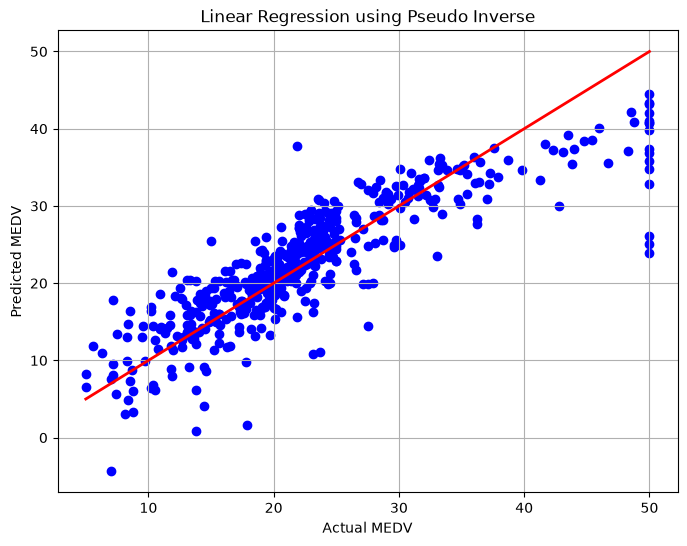

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(y, y_pred, color="blue")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color="red",
         linewidth=2)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Linear Regression using Pseudo Inverse")

plt.grid(True)

plt.show()